In [25]:
import great_expectations as ge
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imp = IterativeImputer(random_state=0)

In [18]:
a = ge.get_context
df_uci = pd.read_parquet('../data/processed/uci_air_quality_cleaned.parquet')

In [19]:
df_uci

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,150.0,11.881723,1045.50,166.000000,1056.25,113.000000,1692.00,1267.50,13.600000,48.875000,0.757754
2004-03-10 19:00:00,2.0,1292.25,112.0,9.397165,954.75,103.000000,1173.75,92.000000,1558.75,972.25,13.300000,47.700001,0.725487
2004-03-10 20:00:00,2.2,1402.00,88.0,8.997817,939.25,131.000000,1140.00,114.000000,1554.50,1074.00,11.900000,53.975002,0.750239
2004-03-10 21:00:00,2.2,1375.50,80.0,9.228796,948.25,172.000000,1092.00,122.000000,1583.75,1203.25,11.000000,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,51.0,6.518224,835.50,131.000000,1205.00,116.000000,1490.00,1110.00,11.150000,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-04-04 10:00:00,3.1,1314.25,NaN,13.529605,1101.25,471.700012,538.50,189.800003,1374.25,1728.50,21.850000,29.250000,0.756824
2005-04-04 11:00:00,2.4,1162.50,NaN,11.355158,1027.00,353.299988,603.75,179.199997,1263.50,1269.00,24.325001,23.725000,0.711864
2005-04-04 12:00:00,2.4,1142.00,NaN,12.374538,1062.50,293.000000,603.25,174.699997,1240.75,1092.00,26.900000,18.350000,0.640649


In [5]:
df_uci.corr()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
CO(GT),1.000000,0.879292,0.889734,0.931091,0.915519,0.795054,-0.703433,0.683533,0.630700,0.854183,0.022113,0.048896,0.048555,0.045123
PT08.S1(CO),0.879292,1.000000,0.790677,0.883821,0.892972,0.713687,-0.771918,0.641696,0.682874,0.899326,0.048628,0.114607,0.135323,-0.002444
NMHC(GT),0.889734,0.790677,1.000000,0.902599,0.877691,0.812685,-0.771111,0.731193,0.853278,0.766731,0.391730,-0.191486,0.269734,0.197097
C6H6(GT),0.931091,0.883821,0.902599,1.000000,0.981962,0.718914,-0.735711,0.614753,0.765717,0.865727,0.198891,-0.061643,0.167909,-0.064352
PT08.S2(NMHC),0.915519,0.892972,0.877691,0.981962,1.000000,0.704483,-0.796687,0.646520,0.777235,0.880590,0.241330,-0.090352,0.186906,-0.084135
NOx(GT),0.795054,0.713687,0.812685,0.718914,0.704483,1.000000,-0.655690,0.763170,0.233777,0.787056,-0.269713,0.221022,-0.149279,0.426570
PT08.S3(NOx),-0.703433,-0.771918,-0.771111,-0.735711,-0.796687,-0.655690,1.000000,-0.652138,-0.538460,-0.796554,-0.145133,-0.056730,-0.232021,-0.257195
NO2(GT),0.683533,0.641696,0.731193,0.614753,0.646520,0.763170,-0.652138,1.000000,0.157678,0.708259,-0.186369,-0.091845,-0.334798,0.371519
PT08.S4(NO2),0.630700,0.682874,0.853278,0.765717,0.777235,0.233777,-0.538460,0.157678,1.000000,0.591137,0.561333,-0.032188,0.629644,-0.526496
PT08.S5(O3),0.854183,0.899326,0.766731,0.865727,0.880590,0.787056,-0.796554,0.708259,0.591137,1.000000,-0.027193,0.124952,0.070738,0.106016


In [20]:
time_diff = df_uci.index.to_series().diff()
time_diff.describe()

count               9356
mean     0 days 01:00:00
std      0 days 00:00:00
min      0 days 01:00:00
25%      0 days 01:00:00
50%      0 days 01:00:00
75%      0 days 01:00:00
max      0 days 01:00:00
Name: DateTime, dtype: object

<Axes: ylabel='DateTime'>

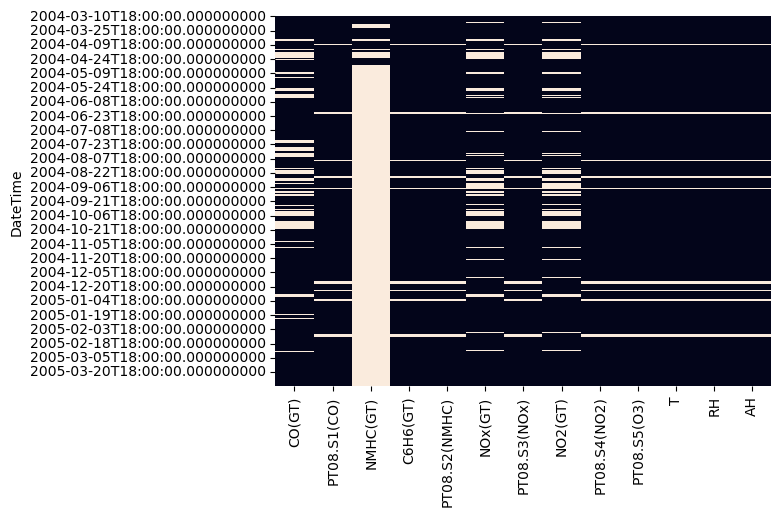

In [22]:
plt.ylabel('Date Time')
sns.heatmap(df_uci.isna(), cbar=False)

In [23]:
df_uci_copy = df_uci.copy()
df_uci_copy.drop(columns=['NMHC(GT)'], inplace=True)

In [24]:
valid = df_uci_copy['CO(GT)'].dropna()
gap = valid.index.to_series().diff()
gap.sort_values(ascending=False)

DateTime
2004-10-20 16:00:00   7 days 06:00:00
2004-04-23 05:00:00   6 days 03:00:00
2004-10-07 16:00:00   5 days 23:00:00
2004-07-31 05:00:00   5 days 03:00:00
2005-01-01 01:00:00   4 days 01:00:00
                            ...      
2004-07-16 18:00:00   0 days 01:00:00
2004-07-16 17:00:00   0 days 01:00:00
2004-07-16 16:00:00   0 days 01:00:00
2005-04-04 14:00:00   0 days 01:00:00
2004-03-10 18:00:00               NaT
Name: DateTime, Length: 7674, dtype: timedelta64[ns]

In [16]:
valid.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       9347, 9348, 9349, 9350, 9351, 9352, 9353, 9354, 9355, 9356],
      dtype='int64', length=7674)

In [28]:
#Hàm để fill na value
def impute_value(df, cols):

    for col in cols:
        df[f"{col}_raw"] = df[col]
        df[f"{col}_imputed"] = df[col].isna()

    df[cols] = (
        df[cols]
        .interpolate(method="time", limit=2)
        .ffill(limit=4)
    )
    df[cols] = imp.fit_transform(df[cols])

    return df

In [29]:
cols = ['CO(GT)','PT08.S1(CO)','C6H6(GT)','PT08.S2(NMHC)','NOx(GT)','PT08.S3(NOx)',	'NO2(GT)','PT08.S4(NO2)',	'PT08.S5(O3)','T','RH','AH']
df_uci_copy = impute_value(df_uci_copy,cols)

In [30]:
df_uci_copy.describe()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,...,C6H6(GT)_raw,PT08.S2(NMHC)_raw,NOx(GT)_raw,PT08.S3(NOx)_raw,NO2(GT)_raw,PT08.S4(NO2)_raw,PT08.S5(O3)_raw,T_raw,RH_raw,AH_raw
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,...,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.097280,1102.311279,10.173825,942.197266,236.540421,832.354309,109.298271,1455.039917,1028.895142,18.248018,...,10.173825,942.197266,236.540421,832.354309,109.298271,1455.039917,1028.895142,18.248018,49.234589,1.021665
std,1.445031,216.692490,7.436249,265.836914,207.632416,255.436722,47.318642,341.167145,400.548401,8.778170,...,7.436249,265.836914,207.632416,255.436722,47.318642,341.167145,400.548401,8.778170,17.167267,0.399839
min,0.030084,647.250000,0.149048,383.250000,-80.206268,56.078857,-6.506104,551.000000,221.000000,-3.463800,...,0.149048,383.250000,-80.206268,56.078857,-6.506104,551.000000,221.000000,-3.463800,9.175000,0.156733
25%,1.000000,940.000000,4.562792,741.000000,92.000000,657.250000,74.000000,1237.381836,738.500000,11.800000,...,4.562792,741.000000,92.000000,657.250000,74.000000,1237.381836,738.500000,11.800000,36.250000,0.739039
50%,1.729824,1066.250000,8.356986,912.500000,173.000000,805.750000,105.000000,1458.750000,968.000000,17.750000,...,8.356986,912.500000,173.000000,805.750000,105.000000,1458.750000,968.000000,17.750000,49.325001,0.994142
75%,2.800000,1234.000000,14.050153,1116.750000,314.000000,965.500000,137.000000,1665.000000,1280.000000,24.175001,...,14.050153,1116.750000,314.000000,965.500000,137.000000,1665.000000,1280.000000,24.175001,62.150002,1.300492
max,11.900000,2039.750000,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2522.750000,44.600002,...,63.741478,2214.000000,1479.000000,2682.750000,339.700012,2775.000000,2522.750000,44.600002,91.666275,2.231036


In [31]:
df_uci_copy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CO(GT)                 9357 non-null   float32
 1   PT08.S1(CO)            9357 non-null   float32
 2   C6H6(GT)               9357 non-null   float32
 3   PT08.S2(NMHC)          9357 non-null   float32
 4   NOx(GT)                9357 non-null   float32
 5   PT08.S3(NOx)           9357 non-null   float32
 6   NO2(GT)                9357 non-null   float32
 7   PT08.S4(NO2)           9357 non-null   float32
 8   PT08.S5(O3)            9357 non-null   float32
 9   T                      9357 non-null   float32
 10  RH                     9357 non-null   float32
 11  AH                     9357 non-null   float32
 12  CO(GT)_raw             9357 non-null   float32
 13  CO(GT)_imputed         9357 non-null   bool   
 14  PT08.S1(CO)_raw     